In [26]:
#experiment-4 => to remove gaussian noise

In [27]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread("giraffe.jpg", cv2.IMREAD_GRAYSCALE)

In [28]:
def add_gaussian_noise(image, mean=0, sigma=50):

    noise = np.random.normal(mean, sigma, image.shape)

    noisy_image = image.astype(np.float32) + noise

    noisy_image = np.clip(noisy_image, 0, 255)

    return noisy_image.astype(np.uint8)

In [29]:
image = cv2.imread("giraffe.jpg", cv2.IMREAD_GRAYSCALE)

noisy_image = add_gaussian_noise(image, mean=0, sigma=50)

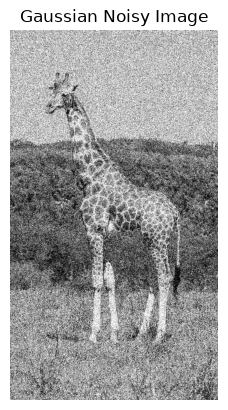

In [30]:
plt.imshow(noisy_image, cmap="gray")
plt.title("Gaussian Noisy Image")
plt.axis("off")
plt.show()


In [31]:
def gaussian_filter(image):

    kernel = np.array([
        [1, 2, 1],
        [2, 4, 2],
        [1, 2, 1]
    ], dtype=np.float32)

    kernel = kernel / 16

    rows, cols = image.shape

    padded = np.pad(image, 1, mode='constant')

    output = np.zeros((rows, cols), dtype=np.uint8)

    for i in range(rows):
        for j in range(cols):

            total = 0.0

            for m in range(3):
                for n in range(3):

                    total += float(padded[i+m][j+n]) * kernel[m][n]

            output[i][j] = np.clip(total, 0, 255)

    return output

In [32]:
filtered_image = gaussian_filter(noisy_image)

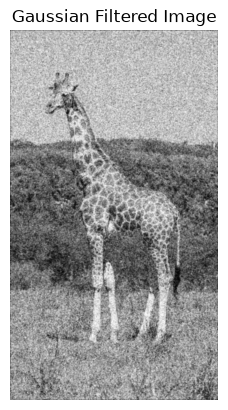

In [33]:
plt.imshow(filtered_image, cmap="gray")
plt.title("Gaussian Filtered Image")
plt.axis("off")
plt.show()